# LLM Security Study — Poster Charts
## Assessing the Security of LLM-Generated Code in Programming Tasks

### Install dependencies using `pip install -r requirements.txt`

| Chart | Type |
|---|---|
| 1 | Grouped bar — Vulnerability Density by model & condition |
| 2 | Grouped bar — Pass Rate by model & condition |
| 3 | Significance heatmap — Wilcoxon results |
| 4 | Scatter — VD vs PR (6 points, labelled by model+condition) |


## 0. Imports, Data & Style

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

FILE     = '../results/aggregate/20260408_174011/combined_scores_summary.xlsx'
by_task  = pd.read_excel(FILE, sheet_name='by_task')
by_model = pd.read_excel(FILE, sheet_name='by_mode_model')
by_mode  = pd.read_excel(FILE, sheet_name='by_mode')

C_BASE = '#4C72B0'
C_SEC  = '#DD8452'

MODEL_LABELS = {
    'claude' : 'Claude Sonnet 4.6',
    'gpt'    : 'GPT-5.4',
    'gemini' : 'Gemini 3'
}
MODEL_ORDER = ['claude', 'gpt', 'gemini']

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 100,
})

print("Setup complete.")


Setup complete.


## Chart 1 — Grouped Bar: Vulnerability Density

Error bars show ± 1 standard deviation across 15 tasks.


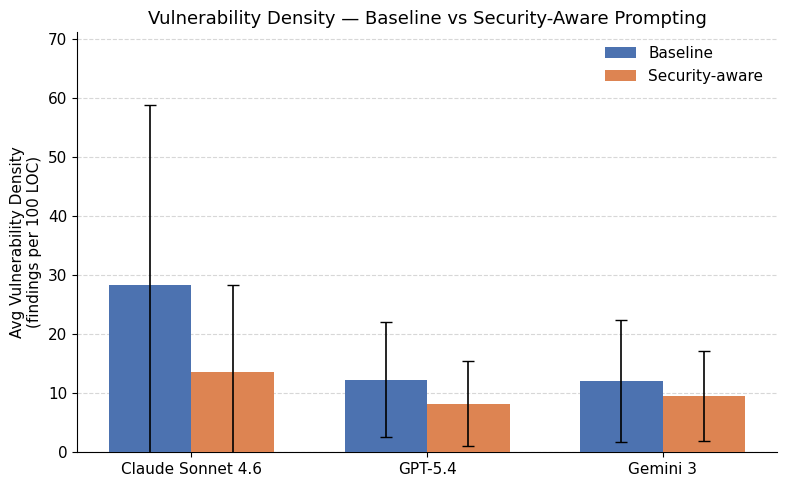

Saved: chart1_vulnerability_density.png


In [2]:
std_vd  = by_task.groupby(['mode','model'])['vulnerability_density'].std().reset_index()
std_vd.columns = ['mode','model','vd_std']
plot_vd = by_model.merge(std_vd, on=['mode','model'])

x     = np.arange(len(MODEL_ORDER))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(MODEL_ORDER):
    base = plot_vd[(plot_vd['model']==model)&(plot_vd['mode']=='baseline')].iloc[0]
    sec  = plot_vd[(plot_vd['model']==model)&(plot_vd['mode']=='security_aware')].iloc[0]

    ax.bar(i - width/2, base['avg_vulnerability_density'], width,
           color=C_BASE, label='Baseline' if i==0 else '', zorder=3)
    ax.bar(i + width/2, sec['avg_vulnerability_density'], width,
           color=C_SEC, label='Security-aware' if i==0 else '', zorder=3)

    ax.errorbar(i - width/2, base['avg_vulnerability_density'],
                yerr=base['vd_std'], fmt='none', color='black', capsize=4, linewidth=1.2, zorder=4)
    ax.errorbar(i + width/2, sec['avg_vulnerability_density'],
                yerr=sec['vd_std'], fmt='none', color='black', capsize=4, linewidth=1.2, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER])
ax.set_ylabel('Avg Vulnerability Density\n(findings per 100 LOC)')
ax.set_title('Vulnerability Density — Baseline vs Security-Aware Prompting')
ax.legend(frameon=False)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart1_vulnerability_density.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: chart1_vulnerability_density.png")


## Chart 2 — Grouped Bar: Pass Rate

Error bars show ± 1 standard deviation across 15 tasks.


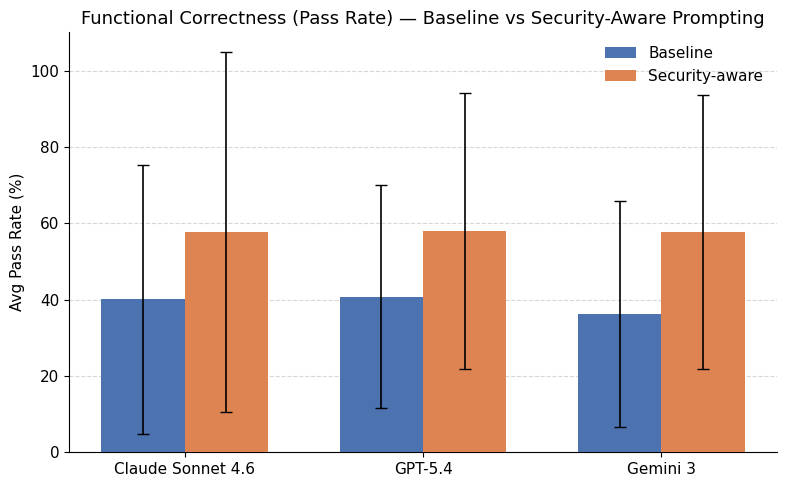

Saved: chart2_pass_rate.png


In [3]:
std_pr  = by_task.groupby(['mode','model'])['pass_rate'].std().reset_index()
std_pr.columns = ['mode','model','pr_std']
plot_pr = by_model.merge(std_pr, on=['mode','model'])

fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(MODEL_ORDER):
    base = plot_pr[(plot_pr['model']==model)&(plot_pr['mode']=='baseline')].iloc[0]
    sec  = plot_pr[(plot_pr['model']==model)&(plot_pr['mode']=='security_aware')].iloc[0]

    ax.bar(i - width/2, base['avg_pass_rate'], width,
           color=C_BASE, label='Baseline' if i==0 else '', zorder=3)
    ax.bar(i + width/2, sec['avg_pass_rate'], width,
           color=C_SEC, label='Security-aware' if i==0 else '', zorder=3)

    ax.errorbar(i - width/2, base['avg_pass_rate'],
                yerr=base['pr_std'], fmt='none', color='black', capsize=4, linewidth=1.2, zorder=4)
    ax.errorbar(i + width/2, sec['avg_pass_rate'],
                yerr=sec['pr_std'], fmt='none', color='black', capsize=4, linewidth=1.2, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER])
ax.set_ylabel('Avg Pass Rate (%)')
ax.set_title('Functional Correctness (Pass Rate) — Baseline vs Security-Aware Prompting')
ax.legend(frameon=False)
ax.set_ylim(0, 110)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart2_pass_rate.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: chart2_pass_rate.png")


## Chart 3 — Significance Heatmap (Wilcoxon Results)

- **Green** — significant (p < 0.05)
- **Amber** — directional (0.05 <= p < 0.20)
- **Red** — not significant (p >= 0.20)


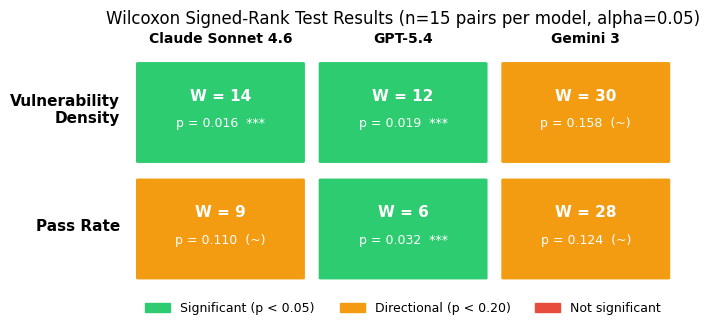

Saved: chart3_significance_heatmap.png


In [4]:
metrics_map = {
    'vulnerability_density' : 'Vulnerability\nDensity',
    'pass_rate'             : 'Pass Rate'
}
wilcoxon_results = {}

for metric_col in metrics_map:
    for model in MODEL_ORDER:
        base = by_task[(by_task['model']==model)&(by_task['mode']=='baseline')].sort_values('task')
        sec  = by_task[(by_task['model']==model)&(by_task['mode']=='security_aware')].sort_values('task')
        merged = base[['task',metric_col]].merge(sec[['task',metric_col]],on='task',suffixes=('_b','_s'))
        b_vals = merged[f'{metric_col}_b'].values
        s_vals = merged[f'{metric_col}_s'].values
        diffs  = b_vals - s_vals
        if np.all(diffs == 0):
            wilcoxon_results[(metric_col, model)] = {'W': 0, 'p': 1.0}
            continue
        stat, p = stats.wilcoxon(b_vals, s_vals, alternative='two-sided')
        wilcoxon_results[(metric_col, model)] = {'W': stat, 'p': p}

metric_cols = list(metrics_map.keys())
n_rows, n_cols = len(metric_cols), len(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.axis('off')

for r, metric_col in enumerate(metric_cols):
    for c, model in enumerate(MODEL_ORDER):
        res = wilcoxon_results[(metric_col, model)]
        p, W = res['p'], res['W']
        if p < 0.05:
            bg, sig_text = '#2ecc71', '***'
        elif p < 0.20:
            bg, sig_text = '#f39c12', '(~)'
        else:
            bg, sig_text = '#e74c3c', '(ns)'
        rect = mpatches.FancyBboxPatch(
            (c + 0.05, n_rows - r - 0.95), 0.90, 0.85,
            boxstyle='round,pad=0.02', facecolor=bg, edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)
        ax.text(c + 0.50, n_rows - r - 0.38, f'W = {W:.0f}',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        ax.text(c + 0.50, n_rows - r - 0.62, f'p = {p:.3f}  {sig_text}',
                ha='center', va='center', fontsize=9, color='white')

for c, model in enumerate(MODEL_ORDER):
    ax.text(c + 0.50, n_rows + 0.05, MODEL_LABELS[model],
            ha='center', va='bottom', fontsize=10, fontweight='bold')

for r, metric_col in enumerate(metric_cols):
    ax.text(-0.05, n_rows - r - 0.50, metrics_map[metric_col],
            ha='right', va='center', fontsize=11, fontweight='bold')

legend_items = [
    mpatches.Patch(color='#2ecc71', label='Significant (p < 0.05)'),
    mpatches.Patch(color='#f39c12', label='Directional (p < 0.20)'),
    mpatches.Patch(color='#e74c3c', label='Not significant'),
]
ax.legend(handles=legend_items, loc='lower center',
          bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=9)
ax.set_title('Wilcoxon Signed-Rank Test Results (n=15 pairs per model, alpha=0.05)',
             pad=20, fontsize=12)
plt.tight_layout()
plt.savefig('chart3_significance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: chart3_significance_heatmap.png")


## Chart 4 — Scatter: Avg Vulnerability Density vs Avg Pass Rate

6 points — one per model x condition.
Arrows show direction of change from baseline to security-aware.
Ideal region = bottom-right (low VD, high PR).


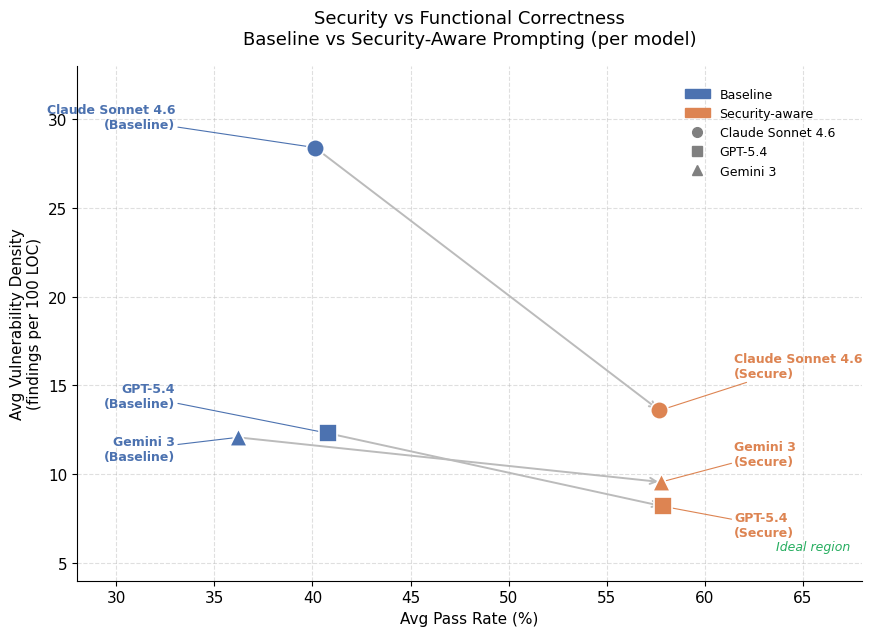

Saved: chart4_scatter_vd_vs_pr.png


In [5]:
MARKERS   = {'claude': 'o', 'gpt': 's', 'gemini': '^'}
CONDITION = {'baseline': C_BASE, 'security_aware': C_SEC}

LABEL_POS = {
    ('claude', 'baseline')       : (33.0, 29.5),
    ('gpt',    'baseline')       : (33.0, 13.8),
    ('gemini', 'baseline')       : (33.0, 10.8),
    ('claude', 'security_aware') : (61.5, 15.5),
    ('gemini', 'security_aware') : (61.5, 10.5),
    ('gpt',    'security_aware') : (61.5,  6.5),
}

fig, ax = plt.subplots(figsize=(9, 6.5))

for model in MODEL_ORDER:
    base = by_model[(by_model['model']==model)&(by_model['mode']=='baseline')].iloc[0]
    sec  = by_model[(by_model['model']==model)&(by_model['mode']=='security_aware')].iloc[0]
    ax.annotate('',
        xy    =(sec['avg_pass_rate'],  sec['avg_vulnerability_density']),
        xytext=(base['avg_pass_rate'], base['avg_vulnerability_density']),
        arrowprops=dict(arrowstyle='->', color='#bbbbbb', lw=1.4,
                        connectionstyle='arc3,rad=0.0')
    )

for _, row in by_model.iterrows():
    model  = row['model']
    mode   = row['mode']
    color  = CONDITION[mode]
    px, py = row['avg_pass_rate'], row['avg_vulnerability_density']

    ax.scatter(px, py, color=color, marker=MARKERS[model], s=160, zorder=5,
               edgecolors='white', linewidths=1.2)

    mode_short = 'Secure' if mode == 'security_aware' else 'Baseline'
    label = f"{MODEL_LABELS[model]}\n({mode_short})"
    lx, ly = LABEL_POS[(model, mode)]

    ax.annotate(label,
                xy=(px, py), xytext=(lx, ly),
                fontsize=9, color=color, fontweight='bold',
                ha='left' if lx > px else 'right',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8,
                                shrinkA=0, shrinkB=4))

ax.text(0.985, 0.06, 'Ideal region', transform=ax.transAxes,
        fontsize=9, color='#27ae60', ha='right', style='italic')

legend_handles = [
    mpatches.Patch(color=C_BASE, label='Baseline'),
    mpatches.Patch(color=C_SEC,  label='Security-aware'),
    plt.Line2D([0],[0], marker='o', color='grey', linestyle='None', markersize=7, label='Claude Sonnet 4.6'),
    plt.Line2D([0],[0], marker='s', color='grey', linestyle='None', markersize=7, label='GPT-5.4'),
    plt.Line2D([0],[0], marker='^', color='grey', linestyle='None', markersize=7, label='Gemini 3'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(0.98, 0.98))

ax.set_xlabel('Avg Pass Rate (%)')
ax.set_ylabel('Avg Vulnerability Density\n(findings per 100 LOC)')
ax.set_title('Security vs Functional Correctness\nBaseline vs Security-Aware Prompting (per model)', pad=16)
ax.set_xlim(28, 68)
ax.set_ylim(4, 33)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart4_scatter_vd_vs_pr.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: chart4_scatter_vd_vs_pr.png")


## Summary

In [6]:
import os
charts = [
    'chart1_vulnerability_density.png',
    'chart2_pass_rate.png',
    'chart3_significance_heatmap.png',
    'chart4_scatter_vd_vs_pr.png',
]
print("Generated files:")
for c in charts:
    size = os.path.getsize(c) // 1024 if os.path.exists(c) else 'MISSING'
    print(f"  {c:45s} {size} KB")


Generated files:
  chart1_vulnerability_density.png              122 KB
  chart2_pass_rate.png                          106 KB
  chart3_significance_heatmap.png               126 KB
  chart4_scatter_vd_vs_pr.png                   287 KB
